# Code Development for the Python Analysis of the Global Rights Data

## Loading libraries

In [1]:
import diversedata as dd
import pandas as pd
import numpy as np
from IPython.display import Markdown

## 1. Data Cleaning and Processing

In [15]:
global_rights = dd.load_data("globalrights")

# Select and clean variables (excluding marriage from transformation)
cleaned_rights = global_rights[
    [
        "country",
        "year",
        "gdp-per-capita",
        "education-spending-gdp",
        "same-sex-marriage",
        "lgbtq-censorship",
        "employment-discrimination",
        "gender-affirming-care",
        "legal-gender",
    ]
]

# Rename columns
cleaned_rights.columns = [
    "country",
    "year",
    "gdp_per_capita",
    "edu_spend",
    "same_sex_marriage",
    "lgbtq_censorship",
    "employment",
    "affirming_care",
    "legal_gender",
]

## 2. Aggregation Plots

In [18]:
import altair as alt

missing_prop = (
    cleaned_rights.isnull()
      .mean()
      .reset_index()
      .rename(columns={"index": "variable", 0: "missing_prop"})
)

chart = alt.Chart(missing_prop).mark_bar().encode(
    x=alt.X("variable", sort="-y"),
    y=alt.Y("missing_prop", axis=alt.Axis(format="%")),
    tooltip=["variable", "missing_prop"]
).properties(
    title="Missing Data per Variable",
    width=400,
    height=300
)

chart

alt.Chart(...)

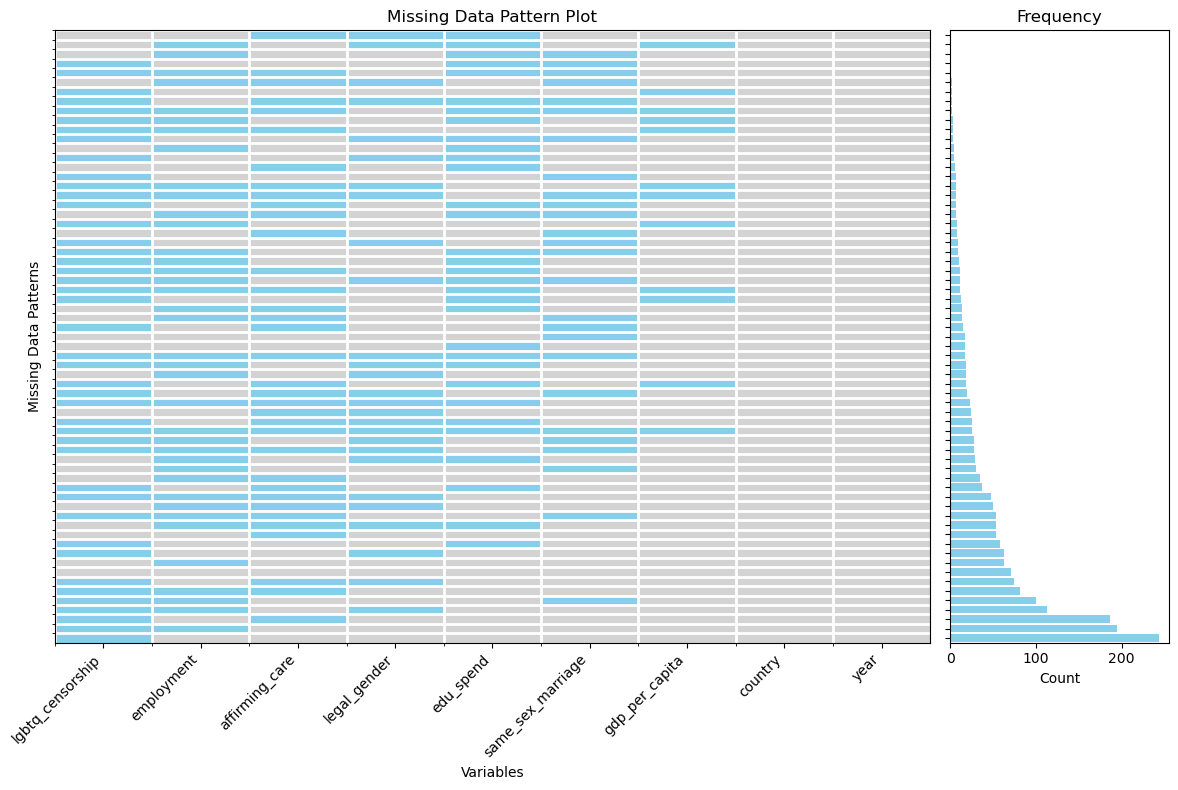

In [98]:
pattern_df = cleaned_rights.isnull().astype(int)
pattern_df = (
    pattern_df.groupby(by=pattern_df.columns.to_list())
    .size()
    .reset_index(name="count")
    .sort_values(by="count")
    .reset_index(drop=True)
)
pattern_df = pattern_df[
    [
        "lgbtq_censorship",
        "employment",
        "affirming_care",
        "legal_gender",
        "edu_spend",
        "same_sex_marriage",
        "gdp_per_capita",
        "country",
        "year",
        "count",
    ]
]
pattern_df_no_count = pattern_df.drop(columns=["count"])

# Create plot
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [4, 1]}
)

# Prepare data for heatmap
pattern_matrix = pattern_df_no_count.astype(bool).to_numpy()

# Custom colormap
colors = ["lightgrey", "skyblue"]
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Main heatmap
im = ax1.imshow(pattern_matrix, cmap=cmap, aspect="auto", interpolation="nearest")

# Set labels
ax1.set_xlabel("Variables")
ax1.set_ylabel("Missing Data Patterns")
ax1.set_title("Missing Data Pattern Plot")

# Set x-axis labels (variable names)
ax1.set_xticks(range(len(pattern_df_no_count.columns)))
ax1.set_xticklabels(pattern_df_no_count.columns, rotation=45, ha="right")

# Set y-axis labels (none)
ax1.set_yticks([])
ax1.set_yticklabels([])

# Add grid
ax1.set_xticks(np.arange(len(pattern_df_no_count.columns)) - 0.5, minor=True)
ax1.set_yticks(np.arange(len(patterns)) - 0.5, minor=True)
ax1.grid(which="minor", color="white", linewidth=2)

# Frequency bar chart - match the spacing of the left plot
counts = pattern_df["count"]
y_positions = np.arange(len(patterns))

# Create bars with same height as the heatmap rows
bar_height = 0.8  # Adjust this to match heatmap cell height
bars = ax2.barh(y_positions, counts, height=bar_height, color="skyblue", align="center")

ax2.set_xlabel("Count")
ax2.set_ylabel("")
ax2.set_yticks(y_positions)
ax2.set_yticklabels([])
ax2.set_title("Frequency")

# Set same y-limits as the main plot to ensure alignment
ax2.set_ylim(ax1.get_ylim())

plt.tight_layout()
plt.show()


## 3. Spinogram and Spineplot

In [ ]:
# move explanation of the R specific function to be in the tab set
# silence R message and improve plot if possible

## 4. MICE using PMM

## 5. Visual Comparison for Before and After Imputation